# Baseline CNN Classifier — Pneumonia vs Healthy

Train `SimpleCNN` on NIH Chest X-ray dataset **without** data augmentation.  
Uses `pos_weight` on `BCEWithLogitsLoss` to deal with unbalanced classes.

**Reported metrics:** Accuracy and AUC-ROC on test dataset.

## 1. Setup

In [1]:
import sys
import os
import json
from pathlib import Path

# Add utils and models to path
project_root = Path("../").resolve()
sys.path.insert(0, str(project_root / "utils"))
sys.path.insert(0, str(project_root / "models"))

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler

from preprocessing import Preprocessing
from classifier import SimpleCNN
from device import DEVICE
from metrics import print_metrics, plot_roc_curve
from train_models import run_epoch, train_model, training_curves, save_results
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

print(f"Device: {DEVICE}")

/Users/mabosco/Desktop/mestrado/IA376N/dgm-2026.1/projects/ecgpcx-ray/env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Device: mps


## 2. Hyperparameters

In [2]:
from config import load_config

cfg = load_config(project_root / "configs" / "baseline_cnn.yaml", project_root)

print(cfg.model.name)              
print(cfg.model.dropout)            
print(cfg.data.img_size)             
print(cfg.data.augmentation)        
print(cfg.data.class_balancing)     
print(cfg.training.batch_size)       
print(cfg.training.lr)                
print(cfg.training.num_epochs)        
print(cfg.training.weight_decay)     
print(cfg.training.early_stopping_patience) 
print(cfg.seed)               

print(cfg.checkpoint_path)            # .../models/baseline_cnn.pt (derivado)
print(cfg.results_dir)                # .../results/baseline_cnn/ (derivado, criado)

SimpleCNN
0.3
[224, 224]
False
pos_weight
64
0.0003
100
0.0001
10
42
/Users/mabosco/Desktop/mestrado/IA376N/dgm-2026.1/projects/ecgpcx-ray/models/baseline_cnn_20260516-164040.pt
/Users/mabosco/Desktop/mestrado/IA376N/dgm-2026.1/projects/ecgpcx-ray/results/baseline_cnn_20260516-164040


In [21]:
IMG_SIZE    = tuple(cfg.data.img_size)
BATCH_SIZE  = cfg.training.batch_size
LR          = cfg.training.lr
NUM_EPOCHS  = cfg.training.num_epochs
DROPOUT     = cfg.model.dropout
SEED        = cfg.seed

CHECKPOINT_PATH = cfg.checkpoint_path
RESULTS_DIR     = cfg.results_dir
RESULTS_DIR.mkdir(exist_ok=True)

## 3. Load Dataset

In [4]:
# prep = Preprocessing(label='Pneumonia')

In [5]:
# train_dataset, test_dataset, val_dataset = prep.create_cvae_dataset(
#     img_size=IMG_SIZE,
#     train_ratio=0.7,
#     val_ratio=0.15,
#     test_ratio=0.15,
#     seed=SEED,
#     verbose=True,
# )
# 
# print(f"\nTrain: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

In [6]:
# import torch
# from pathlib import Path
# 
# DATA_CACHE_DIR = project_root / "data" / "processed"
# DATA_CACHE_DIR.mkdir(parents=True, exist_ok=True)
# 
# torch.save(train_dataset, DATA_CACHE_DIR / "train_dataset.pt")
# torch.save(val_dataset,   DATA_CACHE_DIR / "val_dataset.pt")
# torch.save(test_dataset,  DATA_CACHE_DIR / "test_dataset.pt")
# 
# print(f"Datasets salvos em {DATA_CACHE_DIR}")

In [22]:
# Para carregar os datasets posteriormente:
DATA_CACHE_DIR = project_root / "data" / "processed"
train_dataset = torch.load(DATA_CACHE_DIR / "train_dataset.pt", weights_only=False)
val_dataset   = torch.load(DATA_CACHE_DIR / "val_dataset.pt", weights_only=False)
test_dataset  = torch.load(DATA_CACHE_DIR / "test_dataset.pt", weights_only=False)

In [8]:
# Use an attenuated pos_weight = sqrt(n_neg / n_pos) instead of the full ratio.
# The naive ratio (~189) tends to over-correct on highly imbalanced sets,
# pushing the model to predict pneumonia for almost everything.
train_labels = train_dataset.labels[:, 1]  # index 1 = pneumonia
n_pos = train_labels.sum().item()
n_neg = len(train_labels) - n_pos
pos_weight = torch.tensor([np.sqrt(n_neg / n_pos)], dtype=torch.float32).to(DEVICE)

print(f"Train — Healthy: {int(n_neg)} | Pneumonia: {int(n_pos)}")
print(f"Raw ratio: {n_neg/n_pos:.2f}")
print(f"Attenuated pos_weight (sqrt): {pos_weight.item():.2f}")

Train — Healthy: 42229 | Pneumonia: 223
Raw ratio: 189.37
Attenuated pos_weight (sqrt): 13.76


In [9]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

## 4. Model, Loss, Optimizer

In [10]:
torch.manual_seed(SEED)

model     = SimpleCNN(dropout_rate=DROPOUT).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

print(model)

SimpleCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
     

## 5. Training Loop

In [11]:
best_val_auc, history = train_model(
    model,
    train_loader,
    val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=NUM_EPOCHS,
    CHECKPOINT_PATH=CHECKPOINT_PATH,
    device=DEVICE,
)

Training:   0%|          | 0/100 [00:00<?, ?epoch/s]

Epoch 01/100 | elapsed_time=84.68s| train_loss=0.2771 | train_auc=0.5427 | val_loss=0.2709 | val_auc=0.6114 ← best 
Epoch 02/100 | elapsed_time=81.86s| train_loss=0.2670 | train_auc=0.6017 | val_loss=0.2775 | val_auc=0.5721 
Epoch 03/100 | elapsed_time=83.09s| train_loss=0.2629 | train_auc=0.6280 | val_loss=0.2768 | val_auc=0.5825 
Epoch 04/100 | elapsed_time=82.28s| train_loss=0.2580 | train_auc=0.6475 | val_loss=0.2712 | val_auc=0.6069 
Epoch 05/100 | elapsed_time=85.49s| train_loss=0.2577 | train_auc=0.6425 | val_loss=0.2833 | val_auc=0.6218 ← best 
Epoch 06/100 | elapsed_time=88.99s| train_loss=0.2586 | train_auc=0.6385 | val_loss=0.2818 | val_auc=0.5920 
Epoch 07/100 | elapsed_time=88.97s| train_loss=0.2552 | train_auc=0.6638 | val_loss=0.2779 | val_auc=0.5891 
Epoch 08/100 | elapsed_time=88.05s| train_loss=0.2535 | train_auc=0.6666 | val_loss=0.2754 | val_auc=0.6411 ← best 
Epoch 09/100 | elapsed_time=84.27s| train_loss=0.2542 | train_auc=0.6691 | val_loss=0.2821 | val_auc=0.5920

## 6. Training Curves

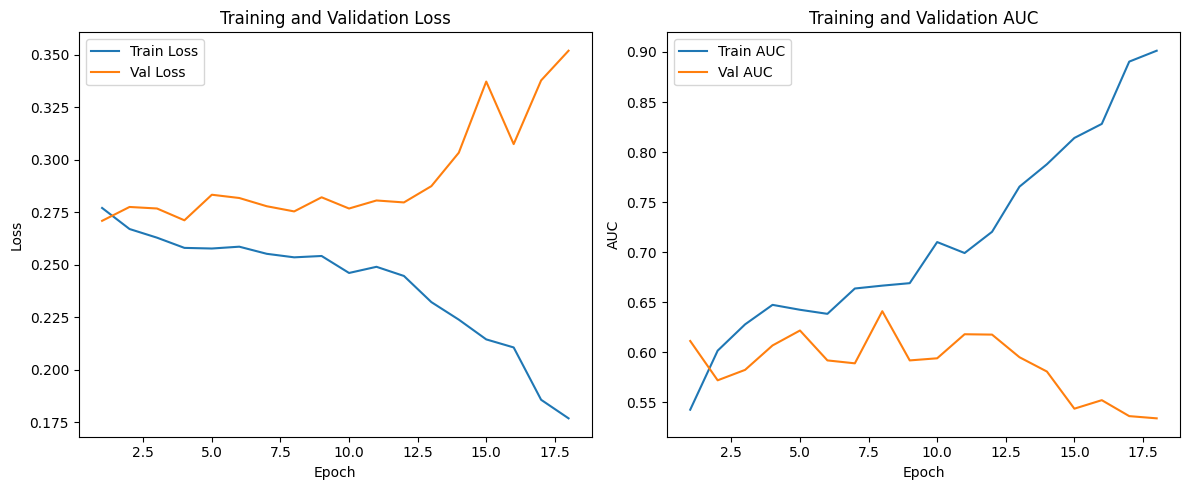

In [14]:
training_curves(history)

## 7. Evaluation on Test Set

In [18]:
# Load best checkpoint
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))

criterion = criterion.to(DEVICE)
_, test_y, test_scores = run_epoch(test_loader, model.to(DEVICE), criterion, device=DEVICE)
_, val_y, val_sc = run_epoch(val_loader, model.to(DEVICE), criterion, device=DEVICE)

from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(val_y, val_sc)
best_threshold = thresholds[np.argmax(tpr - fpr)]

print("=== Test Set Metrics ===")
print_metrics(test_y, test_scores, threshold=best_threshold)

=== Test Set Metrics ===
Accuracy : 0.5754
AUC-ROC  : 0.6668
Confusion matrix (threshold=0.09332306683063507):
  TN=5390  FP=3985
  FN=17  TP=33


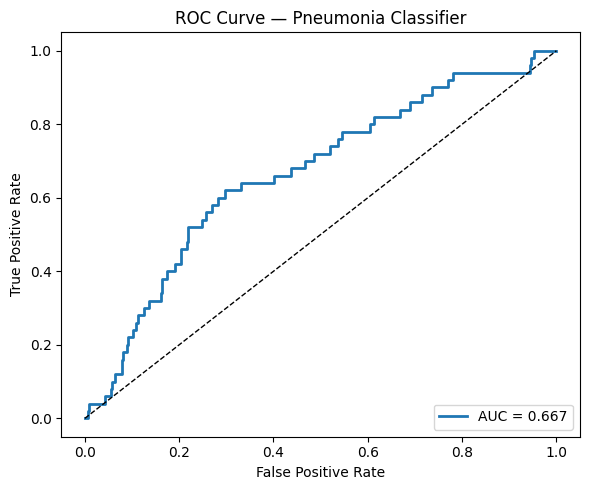

In [19]:
fig = plot_roc_curve(test_y, test_scores, save_path=RESULTS_DIR / "roc_curve.png")
plt.show()

## 8. Save Results

In [20]:
from metrics import compute_accuracy, compute_roc_auc

results = {
    "model": cfg.model.name,
    "img_size": list(IMG_SIZE),
    "epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "dropout": DROPOUT,
    "seed": SEED,
    "class_balancing": cfg.data.class_balancing,
    "best_val_auc": round(best_val_auc, 4),
    "test_accuracy": round(compute_accuracy(test_y, test_scores), 4),
    "test_auc_roc":  round(compute_roc_auc(test_y, test_scores), 4),
    "history": history,
}

results_path = RESULTS_DIR / "baseline_results.json"
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {results_path}")
print(json.dumps({k: v for k, v in results.items() if k != 'history'}, indent=2))

Results saved to /Users/mabosco/Desktop/mestrado/IA376N/dgm-2026.1/projects/ecgpcx-ray/results/baseline_cnn_20260516-164040/baseline_results.json
{
  "model": "SimpleCNN",
  "img_size": [
    224,
    224
  ],
  "epochs": 100,
  "batch_size": 64,
  "lr": 0.0003,
  "dropout": 0.3,
  "seed": 42,
  "class_balancing": "pos_weight",
  "best_val_auc": 0.6411,
  "test_accuracy": 0.9947,
  "test_auc_roc": 0.6668
}
